<a href="https://colab.research.google.com/github/majumdarmanjari14-commits/PCB-defect-detector/blob/main/03_04_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [11]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image

crops_csv_path = os.path.join(DATA_DIR, 'crops_labels.csv')
crops_df = pd.read_csv(crops_csv_path)

print(f"Total crops loaded: {len(crops_df)}")
print(crops_df['label'].value_counts().sort_index())

Total crops loaded: 10013
label
1    1942
2    1506
3    1965
4    1625
5    1474
6    1501
Name: count, dtype: int64


In [12]:
defect_names = {0: 'short circuit', 1: 'mouse bite', 2: 'spur',
                 3: 'copper', 4: 'pin hole', 5: 'unknown/other'}

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class PCBDefectDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['crop_path']).convert('RGB')
        label = int(row['label']) - 1
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_df, val_df = train_test_split(
    crops_df, test_size=0.2, stratify=crops_df['label'], random_state=42
)

train_dataset = PCBDefectDataset(train_df, transform=train_transform)
val_dataset = PCBDefectDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 251
Val batches: 63


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [14]:
import timm

model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=6)
model = model.to(device)

print("Model loaded.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model loaded.
Total parameters: 4,015,234


In [15]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Trainable parameters: 7,686 / 4,015,234


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
print("Loss function and optimizer ready.")

Loss function and optimizer ready.


In [17]:
from sklearn.metrics import f1_score
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(all_labels)
    epoch_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1

print("Training functions defined.")

Training functions defined.


In [18]:
NUM_EPOCHS_PHASE1 = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS_PHASE1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_PHASE1} ({elapsed:.1f}s) | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} f1: {val_f1:.4f}")

Epoch 1/5 (36.6s) | Train loss: 2.1697 acc: 0.3929 | Val loss: 1.7331 acc: 0.4703 f1: 0.4706
Epoch 2/5 (33.6s) | Train loss: 1.3410 acc: 0.5598 | Val loss: 1.4410 acc: 0.5352 f1: 0.5397
Epoch 3/5 (37.1s) | Train loss: 1.1610 acc: 0.6131 | Val loss: 1.3013 acc: 0.5572 f1: 0.5731
Epoch 4/5 (35.5s) | Train loss: 1.0161 acc: 0.6526 | Val loss: 1.1631 acc: 0.6021 f1: 0.6138
Epoch 5/5 (35.4s) | Train loss: 0.9177 acc: 0.6790 | Val loss: 1.0235 acc: 0.6515 f1: 0.6543


In [19]:
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print("New optimizer created with lower LR for fine-tuning.")

Trainable parameters: 4,015,234 / 4,015,234
New optimizer created with lower LR for fine-tuning.


In [20]:
NUM_EPOCHS_PHASE2 = 15
best_val_f1 = 0.0
best_model_path = os.path.join(MODELS_DIR, 'best_model.pth')

for epoch in range(NUM_EPOCHS_PHASE2):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    elapsed = time.time() - start
    improved = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        improved = " <- saved (best so far)"
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_PHASE2} ({elapsed:.1f}s) | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} f1: {val_f1:.4f}{improved}")

print(f"\nBest val F1 achieved: {best_val_f1:.4f}")
print(f"Best model saved to: {best_model_path}")

Epoch 1/15 (49.0s) | Train loss: 0.3298 acc: 0.8890 | Val loss: 0.1865 acc: 0.9386 f1: 0.9403 <- saved (best so far)
Epoch 2/15 (52.4s) | Train loss: 0.0980 acc: 0.9705 | Val loss: 0.1009 acc: 0.9710 f1: 0.9718 <- saved (best so far)
Epoch 3/15 (48.8s) | Train loss: 0.0571 acc: 0.9800 | Val loss: 0.1299 acc: 0.9675 f1: 0.9689
Epoch 4/15 (49.0s) | Train loss: 0.0377 acc: 0.9898 | Val loss: 0.0820 acc: 0.9805 f1: 0.9805 <- saved (best so far)
Epoch 5/15 (49.0s) | Train loss: 0.0295 acc: 0.9889 | Val loss: 0.0634 acc: 0.9850 f1: 0.9853 <- saved (best so far)
Epoch 6/15 (49.7s) | Train loss: 0.0205 acc: 0.9941 | Val loss: 0.0640 acc: 0.9835 f1: 0.9838
Epoch 7/15 (49.3s) | Train loss: 0.0188 acc: 0.9941 | Val loss: 0.0574 acc: 0.9850 f1: 0.9856 <- saved (best so far)
Epoch 8/15 (48.2s) | Train loss: 0.0086 acc: 0.9979 | Val loss: 0.0681 acc: 0.9825 f1: 0.9824
Epoch 9/15 (49.3s) | Train loss: 0.0106 acc: 0.9969 | Val loss: 0.0777 acc: 0.9820 f1: 0.9823
Epoch 10/15 (48.8s) | Train loss: 0.017

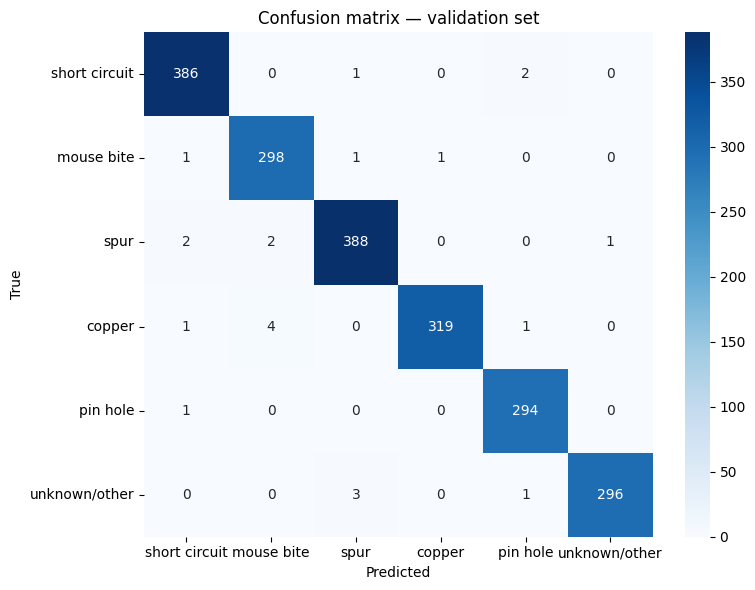


Classification report:
               precision    recall  f1-score   support

short circuit       0.99      0.99      0.99       389
   mouse bite       0.98      0.99      0.99       301
         spur       0.99      0.99      0.99       393
       copper       1.00      0.98      0.99       325
     pin hole       0.99      1.00      0.99       295
unknown/other       1.00      0.99      0.99       300

     accuracy                           0.99      2003
    macro avg       0.99      0.99      0.99      2003
 weighted avg       0.99      0.99      0.99      2003



In [23]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = [defect_names[i] for i in range(6)]
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix — validation set')
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

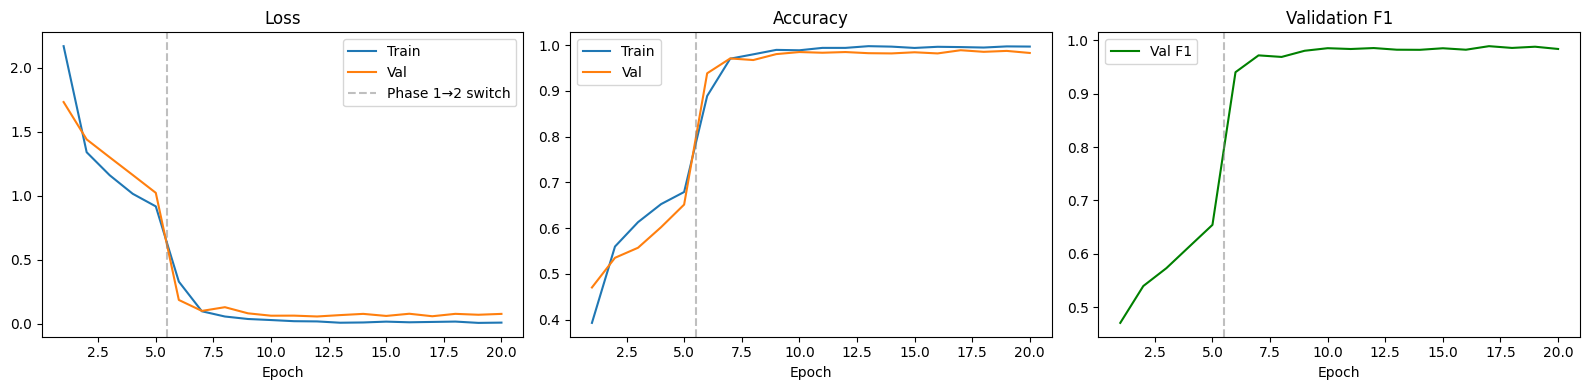

In [24]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Val')
axes[0].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2 switch')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'], label='Val')
axes[1].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs, history['val_f1'], label='Val F1', color='green')
axes[2].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Validation F1')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

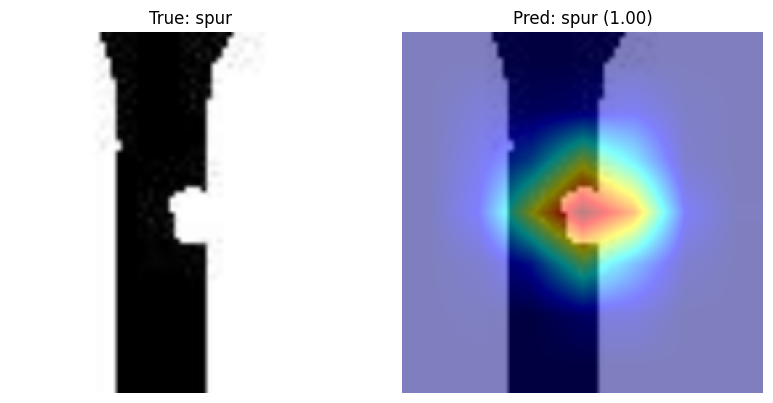

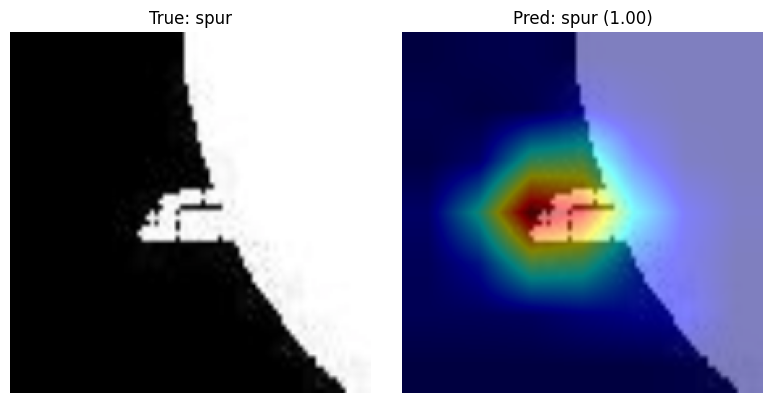

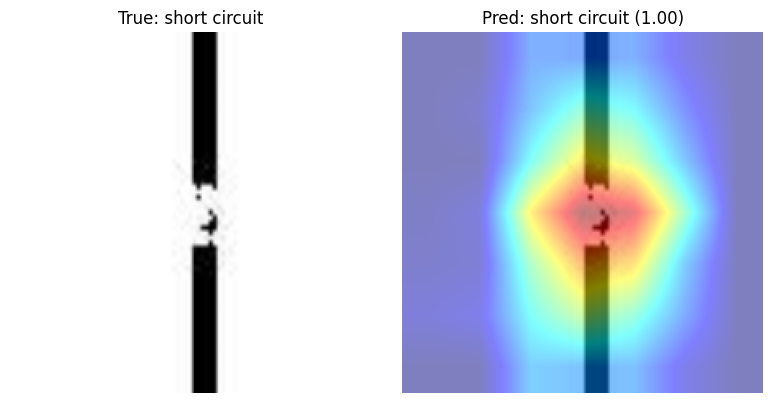

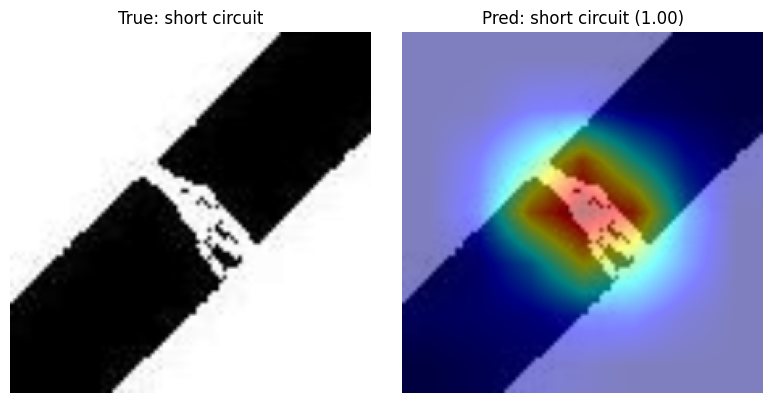

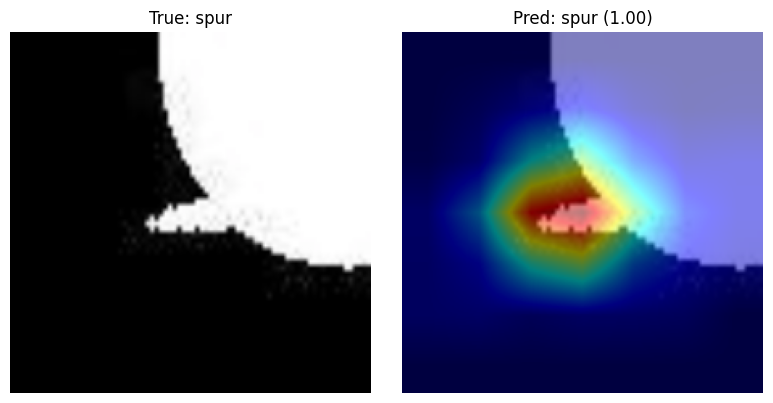

In [25]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch.nn.functional as F

target_layer = [model.conv_head]
cam = GradCAM(model=model, target_layers=target_layer)

def show_gradcam(idx, dataset, original_df):
    img, label = dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    img_unnorm = unnormalize(img).permute(1, 2, 0).clamp(0, 1).numpy()
    visualization = show_cam_on_image(img_unnorm, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(1).item()
        conf = F.softmax(output, dim=1)[0][pred].item()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_unnorm)
    axes[0].set_title(f'True: {defect_names[label]}')
    axes[0].axis('off')
    axes[1].imshow(visualization)
    axes[1].set_title(f'Pred: {defect_names[pred]} ({conf:.2f})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

def unnormalize(img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img * std + mean

for i in range(5):
    show_gradcam(i, val_dataset, val_df)

In [26]:
import json

# Save training history
history_path = os.path.join(LOGS_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

# Save class mapping (critical for deployment later)
class_mapping = {str(k): v for k, v in defect_names.items()}
mapping_path = os.path.join(MODELS_DIR, 'class_mapping.json')
with open(mapping_path, 'w') as f:
    json.dump(class_mapping, f, indent=2)

print("Saved training history:", os.path.exists(history_path))
print("Saved class mapping:", os.path.exists(mapping_path))
print(f"\nBest model already saved at: {best_model_path}")
print(f"Best val F1: {best_val_f1:.4f}")

Saved training history: True
Saved class mapping: True

Best model already saved at: /content/drive/MyDrive/pcb-defect-detection/models/best_model.pth
Best val F1: 0.9891
